# 01 — Data Loading (COCO subset)

Loads a small COCO subset (N classes x M images/class) for the YOLOv3 demo.
Keeping the subset small is what makes the *training* notebook finish in a
reasonable time on a single PC GPU — everything downstream (model, loss,
Tucker-2 decomposition) is unaffected by this choice and will work the same
on the full COCO dataset if you swap it in later.

**Requires:** COCO `annotations/instances_{split}.json` + image folders under `DATA_ROOT`.
Get them from https://cocodataset.org/#download (2017 train/val + annotations).

In [2]:
import sys, os
sys.path.append(os.path.abspath("../src"))
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from dataset import CocoSubsetDataset, yolo_collate_fn

## Config — edit these for your machine / demo

In [3]:
DATA_ROOT = "/tf/shared_data/yolo_tucker/data/coco"          # expects DATA_ROOT/annotations, DATA_ROOT/train2017, DATA_ROOT/val2017
CLASS_NAMES = ["person", "car", "dog", "chair", "bottle"]   # small, visually distinct subset
IMAGES_PER_CLASS = 150              # ~750 images total train -> a few minutes/epoch on a single GPU
IMG_SIZE = 416
BATCH_SIZE = 8

In [4]:
train_ds = CocoSubsetDataset(DATA_ROOT, "train2017", CLASS_NAMES,
                              img_size=IMG_SIZE, images_per_class=IMAGES_PER_CLASS, augment=True)
val_ds = CocoSubsetDataset(DATA_ROOT, "val2017", CLASS_NAMES,
                            img_size=IMG_SIZE, images_per_class=max(20, IMAGES_PER_CLASS // 5), augment=False)

print(f"train images: {len(train_ds)}  val images: {len(val_ds)}  classes: {train_ds.num_classes}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=yolo_collate_fn, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=yolo_collate_fn, num_workers=2)

loading annotations into memory...
Done (t=10.48s)
creating index...
index created!
loading annotations into memory...
Done (t=0.48s)
creating index...
index created!
train images: 748  val images: 148  classes: 5


## Sanity check — visualize one batch with its boxes

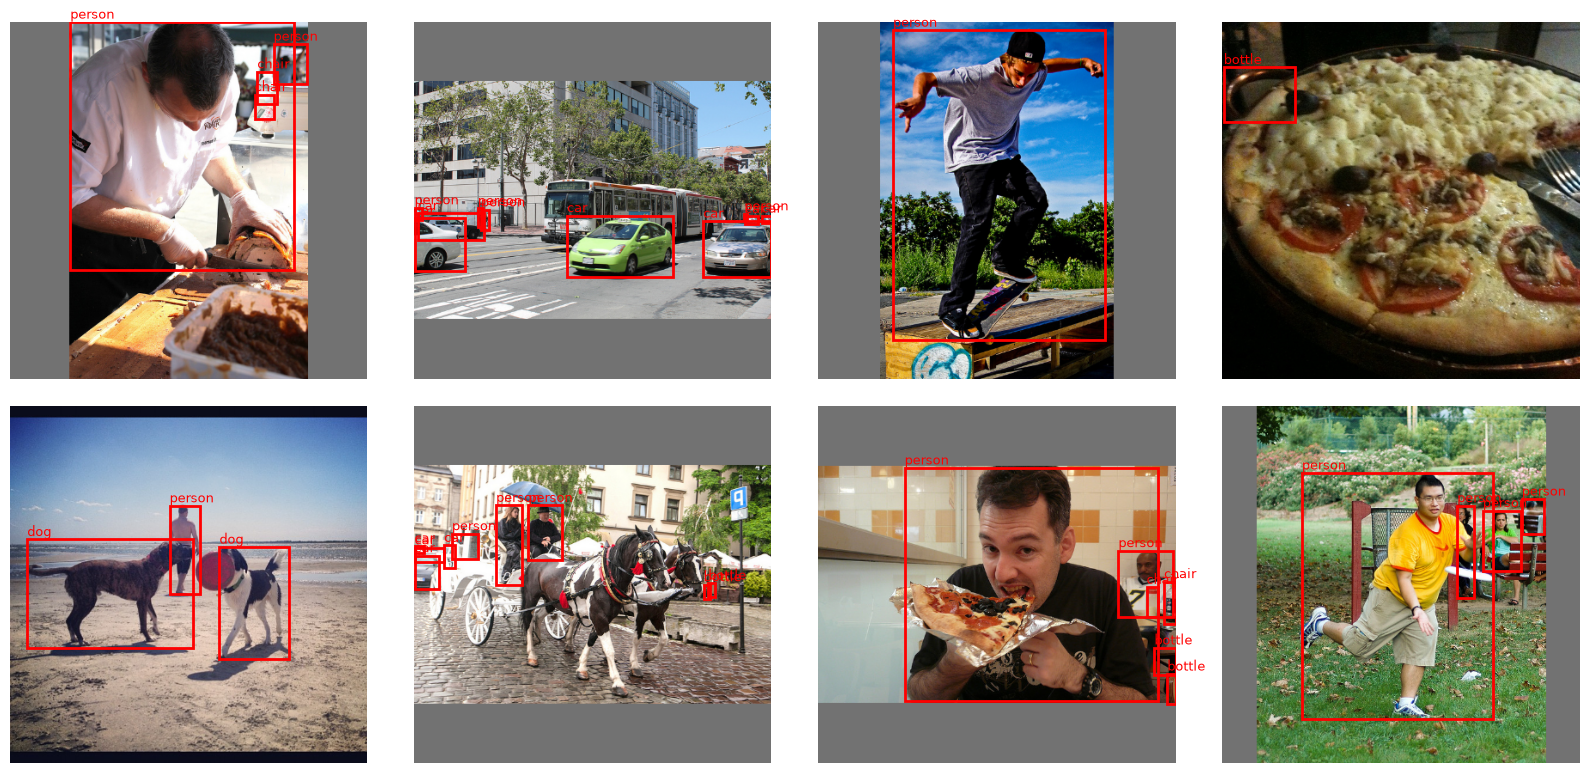

In [5]:
imgs, targets = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= imgs.shape[0]:
        ax.axis("off"); continue
    img = imgs[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    for box in targets[i]:
        cls, cx, cy, w, h = box.tolist()
        x0, y0 = (cx - w/2) * IMG_SIZE, (cy - h/2) * IMG_SIZE
        rect = plt.Rectangle((x0, y0), w * IMG_SIZE, h * IMG_SIZE, fill=False, edgecolor="red", linewidth=2)
        ax.add_patch(rect)
        ax.text(x0, y0 - 4, CLASS_NAMES[int(cls)], color="red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Save the config for the other notebooks

So `02_model_definition`, `03_training`, `04_decomposition`, `05_analysis` all agree on
`CLASS_NAMES` / `IMG_SIZE` without re-typing them.

In [6]:
import json
os.makedirs("../checkpoints", exist_ok=True)
with open("../checkpoints/run_config.json", "w") as f:
    json.dump({"class_names": CLASS_NAMES, "img_size": IMG_SIZE,
               "data_root": DATA_ROOT, "batch_size": BATCH_SIZE}, f, indent=2)
print("saved ../checkpoints/run_config.json")

saved ../checkpoints/run_config.json
